In [64]:
!pip install ydata-profiling xgboost openpyxl

In [65]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from ydata_profiling import ProfileReport

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib
import warnings
warnings.filterwarnings("ignore")


# Upload Dataset in Colab

In [66]:
from google.colab import files

uploaded = files.upload()

Saving 1_loan_approval_dataset.xlsx to 1_loan_approval_dataset.xlsx


#Load Dataset

In [67]:
data = pd.read_excel('1_loan_approval_dataset (1).xlsx', engine="openpyxl")
data.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


#Basic Data Understanding

In [68]:
print("Shape of dataset:", data.shape)

data.info()

Shape of dataset: (4269, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [69]:
data.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [70]:
data.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


#Data Profiling Report

In [71]:
profile = ProfileReport(
    data,
    title="Loan Approval Dataset Profiling Report",
    explorative=True
)

profile.to_file("loan_approval_profile_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:00<00:00, 47.43it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

#Target Class Distribution

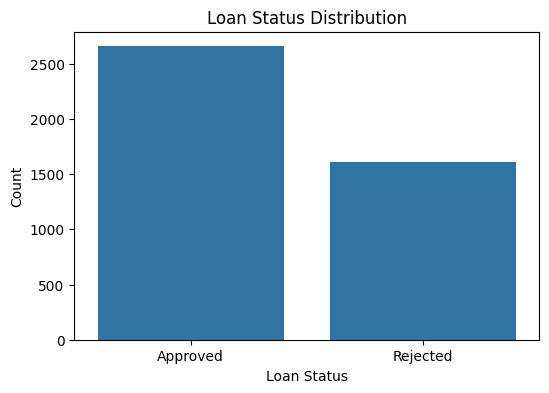

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64
loan_status
Approved    62.215976
Rejected    37.784024
Name: proportion, dtype: float64


In [72]:
plt.figure(figsize=(6,4))
sns.countplot(data=data, x="loan_status")
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

print(data["loan_status"].value_counts())
print(data["loan_status"].value_counts(normalize=True) * 100)

#Correlation Heatmap

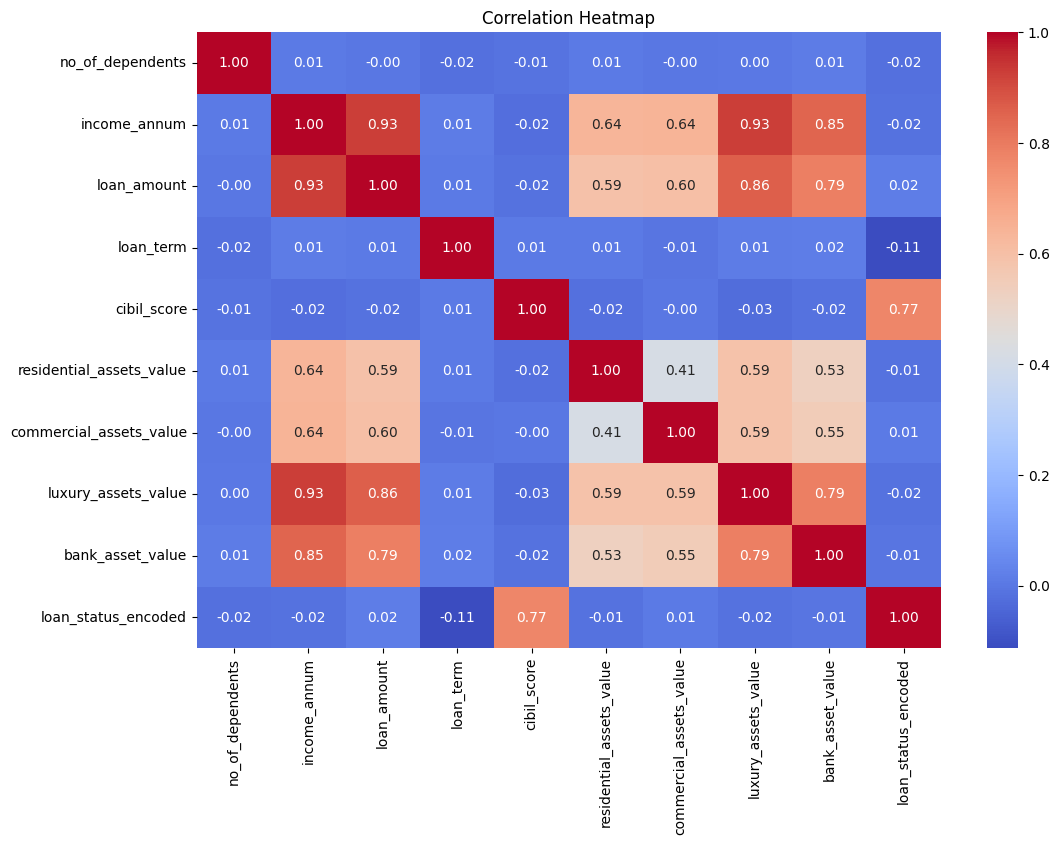

In [73]:
data_corr = data.copy()

if "loan_id" in data_corr.columns:
    data_corr = data_corr.drop("loan_id", axis=1)

data_corr["loan_status_encoded"] = data_corr["loan_status"].map({
    "Approved": 1,
    "Rejected": 0
})

numeric_data = data_corr.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


#Outlier Check Using Boxplot

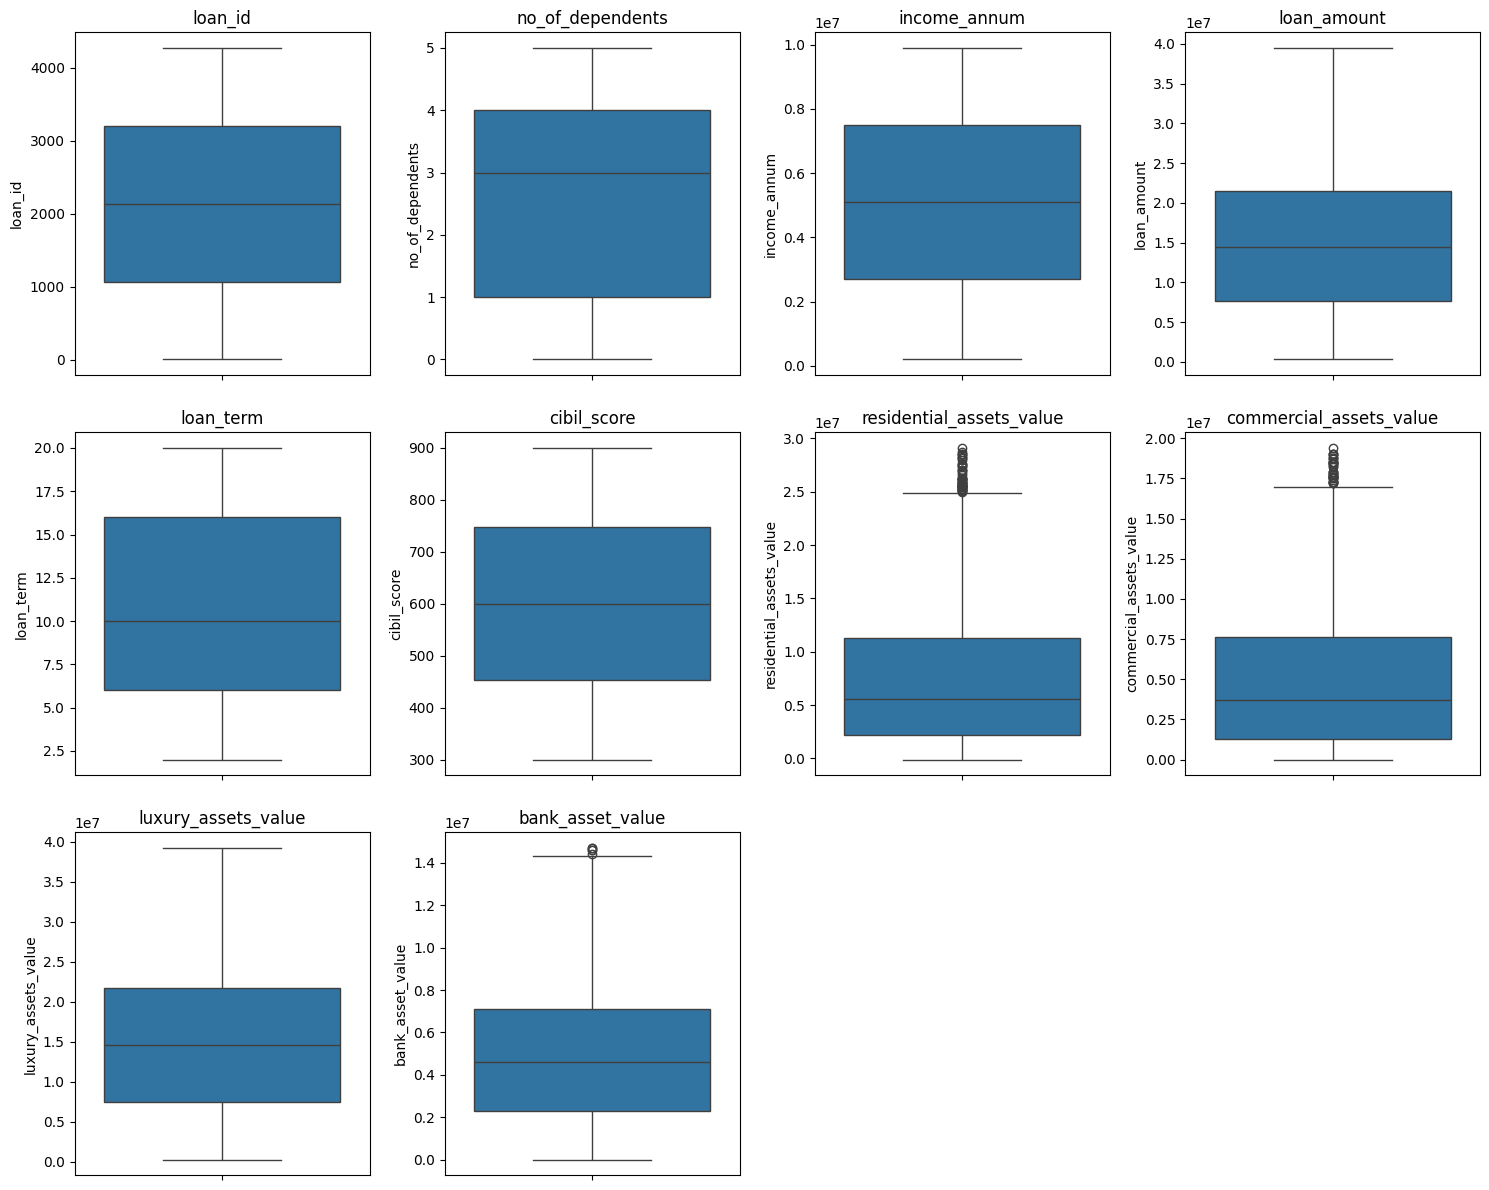

In [74]:
numeric_columns = data.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(15, 12))

for i, col in enumerate(numeric_columns, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(y=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

#feature engineering

In [75]:
df = data.copy()

df["loan_to_income_ratio"] = df["loan_amount"] / df["income_annum"]

df["total_asset_value"] = (
    df["residential_assets_value"] +
    df["commercial_assets_value"] +
    df["luxury_assets_value"] +
    df["bank_asset_value"]
)

df["asset_to_loan_ratio"] = df["total_asset_value"] / df["loan_amount"]

df.replace([np.inf, -np.inf], np.nan, inplace=True)

df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,loan_to_income_ratio,total_asset_value,asset_to_loan_ratio
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved,3.114583,50700000,1.695652
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected,2.975610,17000000,1.393443
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected,3.263736,57700000,1.942761
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected,3.743902,52700000,1.716612
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected,2.469388,55000000,2.272727


#Separate Feature And Target

In [76]:
if "loan_id" in df.columns:
    df = df.drop("loan_id", axis=1)

X = df.drop("loan_status", axis=1)

y = df["loan_status"].map({
    "Approved": 1,
    "Rejected": 0
})

print(X.head())
print(y.head())

   no_of_dependents     education self_employed  income_annum  loan_amount  \
0                 2      Graduate            No       9600000     29900000   
1                 0  Not Graduate           Yes       4100000     12200000   
2                 3      Graduate            No       9100000     29700000   
3                 3      Graduate            No       8200000     30700000   
4                 5  Not Graduate           Yes       9800000     24200000   

   loan_term  cibil_score  residential_assets_value  commercial_assets_value  \
0         12          778                   2400000                 17600000   
1          8          417                   2700000                  2200000   
2         20          506                   7100000                  4500000   
3          8          467                  18200000                  3300000   
4         20          382                  12400000                  8200000   

   luxury_assets_value  bank_asset_value  loan_to_

In [77]:
print(y.value_counts())
print(y.isnull().sum())

loan_status
1    2656
0    1613
Name: count, dtype: int64
0


#Train Test Split

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3415, 14)
Testing data: (854, 14)


#Column Transfer Preprocessing

In [79]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numeric Features:", numeric_features.tolist())
print("Categorical Features:", categorical_features.tolist())

Numeric Features: ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_to_income_ratio', 'total_asset_value', 'asset_to_loan_ratio']
Categorical Features: ['education', 'self_employed']


In [80]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

#Compare Different Models

In [81]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42)
}

model_results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    model_results[name] = scores.mean()

    print(f"{name}")
    print(f"Mean CV Accuracy: {scores.mean():.4f}")
    print(f"Standard Deviation: {scores.std():.4f}")
    print("-" * 50)


Logistic Regression
Mean CV Accuracy: 0.9098
Standard Deviation: 0.0073
--------------------------------------------------
Decision Tree
Mean CV Accuracy: 0.9991
Standard Deviation: 0.0018
--------------------------------------------------
Random Forest
Mean CV Accuracy: 0.9982
Standard Deviation: 0.0023
--------------------------------------------------
Gradient Boosting
Mean CV Accuracy: 0.9988
Standard Deviation: 0.0017
--------------------------------------------------
XGBoost
Mean CV Accuracy: 0.9974
Standard Deviation: 0.0027
--------------------------------------------------


#Show Model Comaprison

In [82]:
results_df = pd.DataFrame({
    "Model": model_results.keys(),
    "CV Accuracy": model_results.values()
}).sort_values(by="CV Accuracy", ascending=False)

results_df

,Model,CV Accuracy
1,Decision Tree,0.999122
3,Gradient Boosting,0.998829
2,Random Forest,0.998243
4,XGBoost,0.997365
0,Logistic Regression,0.909810


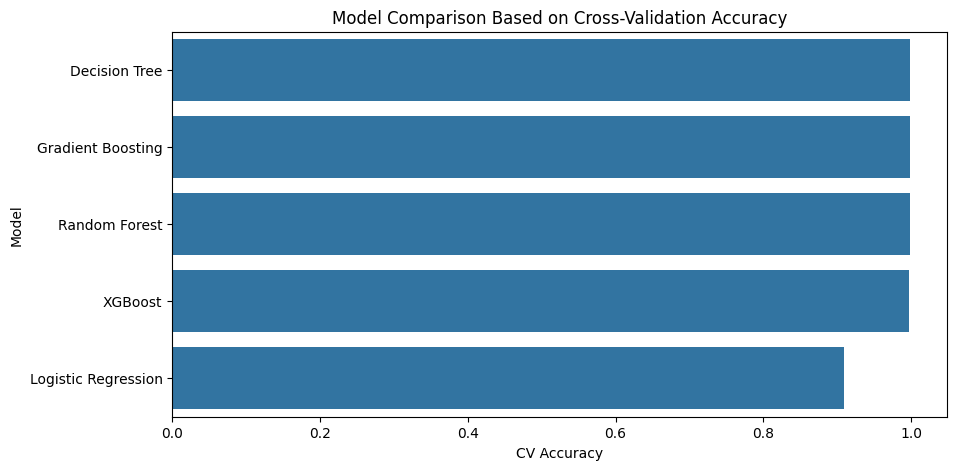

In [83]:
plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x="CV Accuracy", y="Model")
plt.title("Model Comparison Based on Cross-Validation Accuracy")
plt.show()

# Hyperparameter Tunning for best Model

In [84]:
gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 4],
    "model__subsample": [0.8, 1.0]
}

grid_search = GridSearchCV(
    gb_pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)


Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best CV Accuracy: 0.9991215226939971


#Final model Evaluation

In [85]:
final_model = grid_search.best_estimator_

y_pred = final_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Rejected", "Approved"]
))

Test Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

    Rejected       1.00      1.00      1.00       323
    Approved       1.00      1.00      1.00       531

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
weighted avg       1.00      1.00      1.00       854



#Confusion Matrix

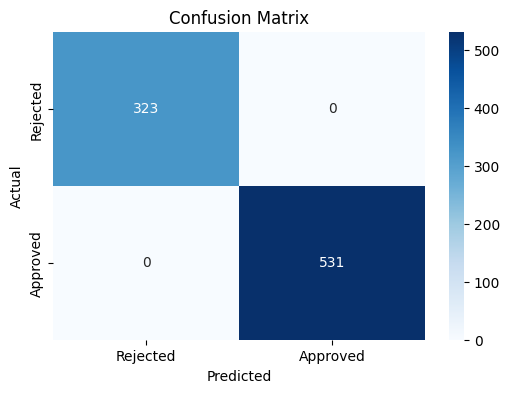

In [86]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#feature Importance

In [87]:
best_gb_model = final_model.named_steps["model"]

feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_gb_model.feature_importances_
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

importance_df.head(15)

,Feature,Importance
4,num__cibil_score,8.095771e-01
9,num__loan_to_income_ratio,9.099574e-02
3,num__loan_term,8.523846e-02
11,num__asset_to_loan_ratio,1.418819e-02
0,num__no_of_dependents,3.951364e-07
5,num__residential_assets_value,9.778196e-08
8,num__bank_asset_value,6.623895e-09
6,num__commercial_assets_value,6.189584e-10
7,num__luxury_assets_value,9.643257e-11
13,cat__education_Not Graduate,3.698933e-11


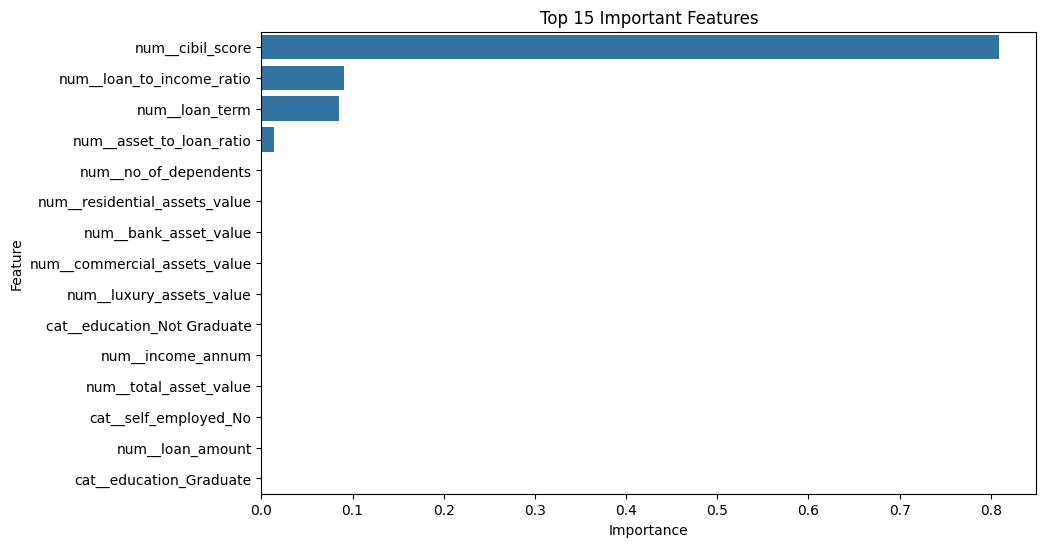

In [88]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")
plt.show()

#test Single prediction

In [89]:
sample = X_test.iloc[[5]]

prediction = final_model.predict(sample)

if prediction[0] == 1:
    print("Loan Approved")
else:
    print("Loan Rejected")

Loan Approved


In [90]:
print(y_test.iloc[5])

1


#Duplicate Rows

In [91]:
print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 0


#Cibil Score by Loan Status

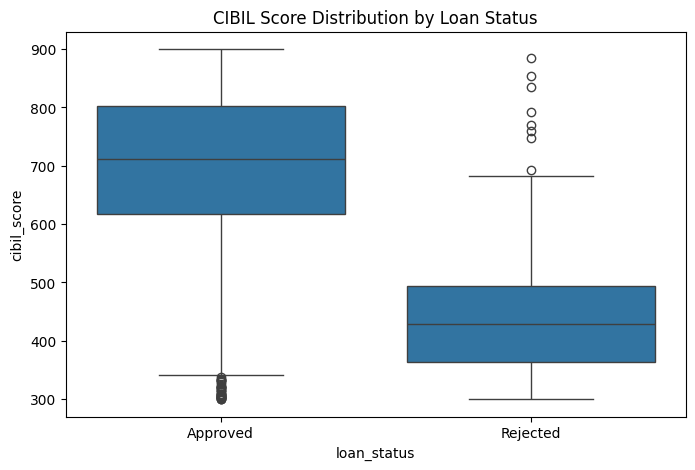

In [92]:
plt.figure(figsize=(8,5))
sns.boxplot(data=data, x="loan_status", y="cibil_score")
plt.title("CIBIL Score Distribution by Loan Status")
plt.show()

In [93]:
data.groupby("loan_status")["cibil_score"].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Approved,2656.0,703.461973,125.249016,300.0,618.0,711.0,803.0,900.0
Rejected,1613.0,429.468072,78.401752,300.0,364.0,429.0,493.0,885.0


#Train Without Cibil Score

In [94]:
X_no_cibil = X.drop("cibil_score", axis=1)

X_train_nc, X_test_nc, y_train_nc, y_test_nc = train_test_split(
    X_no_cibil,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

numeric_features_nc = X_no_cibil.select_dtypes(include=["int64", "float64"]).columns
categorical_features_nc = X_no_cibil.select_dtypes(include=["object"]).columns

preprocessor_nc = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features_nc),
        ("cat", categorical_transformer, categorical_features_nc)
    ]
)

model_no_cibil = Pipeline(steps=[
    ("preprocessor", preprocessor_nc),
    ("model", GradientBoostingClassifier(random_state=42))
])

model_no_cibil.fit(X_train_nc, y_train_nc)

y_pred_nc = model_no_cibil.predict(X_test_nc)

print("Accuracy without CIBIL Score:", accuracy_score(y_test_nc, y_pred_nc))
print(classification_report(y_test_nc, y_pred_nc, target_names=["Rejected", "Approved"]))

Accuracy without CIBIL Score: 0.6182669789227166
              precision    recall  f1-score   support

    Rejected       0.48      0.10      0.16       323
    Approved       0.63      0.93      0.75       531

    accuracy                           0.62       854
   macro avg       0.55      0.52      0.46       854
weighted avg       0.57      0.62      0.53       854



#Save Model

In [95]:
joblib.dump(final_model, "loan_approval_prediction_model.pkl")

['loan_approval_prediction_model.pkl']

In [96]:
files.download("loan_approval_prediction_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os

for file in os.listdir('/content'):
    if file.endswith('.ipynb'):
        os.system(f'jupyter nbconvert --to script "{file}" -o /content/drive/MyDrive/loan_pred')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
